# GEDI on text data: 20 Newsgroups

This notebook evaluates the GEDI clustering model on **20 Newsgroups** text data — a domain entirely absent from the original paper. Documents are embedded with a pre-trained sentence-transformer (`all-MiniLM-L6-v2`) into 384-dimensional vectors, then clustered with GEDI and KMeans for comparison.

In [1]:
from collections import defaultdict
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.manifold import TSNE

from src.metrics import evaluate_clustering
from src.model import GEDIConfig, GEDIModel, gedi_predict, train_gedi
from src.utils import set_random_seed

set_random_seed(0)


## 1. Load 20 Newsgroups (5 topics, ≤500 docs/topic)
We select 5 well-separated topics and subsample to at most 500 documents each to keep runtime manageable. Headers, footers, and quoted replies are stripped to reduce noise.

In [2]:
CATEGORIES = [
    'alt.atheism',
    'comp.graphics',
    'rec.sport.baseball',
    'sci.med',
    'talk.politics.guns',
]
MAX_PER_CLASS = 500
N_CLUSTERS = len(CATEGORIES)

news = fetch_20newsgroups(
    subset='all',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),
    random_state=0,
)

# Subsample to at most MAX_PER_CLASS per category
by_class = defaultdict(list)
for text, label in zip(news.data, news.target):
    by_class[label].append(text)

texts, y_list = [], []
rng = np.random.RandomState(0)
for label in sorted(by_class):
    docs = by_class[label]
    idx = rng.choice(len(docs), size=min(MAX_PER_CLASS, len(docs)), replace=False)
    for i in idx:
        texts.append(docs[i])
        y_list.append(label)

y = np.array(y_list, dtype=int)
print(f"Total documents : {len(texts)}")
print(f"Classes         : {np.unique(y).tolist()}")
print(f"Docs per class  : {[int((y == c).sum()) for c in np.unique(y)]}")

info_df = pd.DataFrame({
    'Category': [CATEGORIES[c] for c in np.unique(y)],
    'Label': np.unique(y),
    'Count': [(y == c).sum() for c in np.unique(y)],
})
display(info_df)


Total documents : 2500
Classes         : [0, 1, 2, 3, 4]
Docs per class  : [500, 500, 500, 500, 500]


,Category,Label,Count
0,alt.atheism,0,500
1,comp.graphics,1,500
2,rec.sport.baseball,2,500
3,sci.med,3,500
4,talk.politics.guns,4,500


## 2. Sentence embeddings (all-MiniLM-L6-v2 → 384 dims)
Each document is encoded into a 384-dimensional vector with a pre-trained sentence-transformer, then L2-normalised.

In [3]:
print("Loading sentence-transformer model…")
st_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding documents…")
X = st_model.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
# Raw embeddings (no L2 normalisation): Gaussian augmentation N(0, 0.05²I) operates
# correctly on unnormalised vectors and preserves the energy landscape assumed by GEDI.

print(f"Embedding shape: {X.shape}")   # (N, 384)


Loading sentence-transformer model…


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding documents…


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Embedding shape: (2500, 384)


## 3. Train GEDI
**Step 1** (this cell): sentence embeddings were computed above — GEDI only receives 384-dim vectors, no text processing inside the training loop.

**Step 2** (this cell): train GEDI with hyperparameters tuned for text:
- Encoder: MLP(384 → 128 → 64), `hidden_dim=64`
- `lambda_prior=100.0` — increased from 10.0; the prior is too weak for 384-dim inputs (toy uses 2-dim, so a 10× increase is appropriate)
- `lambda_inv=100.0` — increased from 50.0; stronger invariance signal needed for higher-dimensional space
- `lambda_gen=0.0` — SGLD (L_GEN) disabled; SGLD adds noise that hurts convergence on text embeddings
- `aug_noise_std=0.15` — increased from 0.05; σ=0.05 is negligibly small relative to 384-dim embedding scale, so L_INV learns no meaningful invariance
- `batch_size=128` — appropriate for ~2500 samples
- `train_iterations=5000` — smaller than toy (20k) since dataset is smaller


In [4]:
SEEDS = list(range(5))

# ── Step 1: disable L_GEN entirely, strengthen L_PRIOR ───────────────────────
# If collapse persists after this, try Step 2 below (comment out Step 1 block).
BASE_CFG = dict(
    in_features=384,
    hidden_dim=64,
    encoder_hidden_dims=[128],   # MLP: 384 → 128 → 64
    n_clusters=N_CLUSTERS,       # 5
    tau=0.1,
    lr=1e-3,
    batch_size=128,
    train_iterations=5000,
    lambda_prior=200.0,          # ↑ from 100 → 200: stronger uniformity push
    lambda_inv=50.0,             # ↓ from 100 → 50:  reduce invariance pressure
    lambda_gen=0.0,              # SGLD disabled (L_GEN=0) — noise hurts convergence
    aug_noise_std=0.15,          # σ for Gaussian augmentation
    sgld_steps=1,
)

# ── Step 2 (activate if Step 1 still collapses) ──────────────────────────────
# Kill L_INV too — only L_PRIOR forces uniform cluster usage.
# BASE_CFG = dict(
#     in_features=384,
#     hidden_dim=64,
#     encoder_hidden_dims=[128],
#     n_clusters=N_CLUSTERS,
#     tau=0.1,
#     lr=1e-3,
#     batch_size=128,
#     train_iterations=5000,
#     lambda_prior=500.0,   # very strong prior — only loss keeping clusters split
#     lambda_inv=0.0,       # L_INV fully off
#     lambda_gen=0.0,       # L_GEN fully off
#     aug_noise_std=0.15,
#     sgld_steps=1,
# )

gedi_rows = []
gedi_best_nmi, gedi_best_pred = -np.inf, None
for seed in SEEDS:
    cfg = GEDIConfig(**BASE_CFG, random_state=seed)
    model = GEDIModel(cfg)
    print(f"Training GEDI (seed={seed})…")
    train_gedi(model, X, cfg)
    y_pred = gedi_predict(model, X)
    scores = evaluate_clustering(X, y, y_pred)
    gedi_rows.append(scores)
    if scores['NMI'] > gedi_best_nmi:
        gedi_best_nmi = scores['NMI']
        gedi_best_pred = y_pred

# Best-seed predictions used for t-SNE (consistent with notebooks 1 & 3)
y_pred_gedi = gedi_best_pred
print(f"Done. Best seed NMI = {gedi_best_nmi:.4f}")


Training GEDI (seed=0)…
Training GEDI (seed=1)…
Training GEDI (seed=2)…
Training GEDI (seed=3)…
Training GEDI (seed=4)…
Done. Best seed NMI = 0.0000


## 4. Evaluate and compare with KMeans baseline
Both supervised (NMI, ARI, ACC) and unsupervised (Silhouette, DBI, CHI) metrics are reported.

In [5]:
metric_columns = ['ACC', 'NMI', 'ARI', 'Silhouette', 'DBI', 'CHI']

# KMeans baseline (single run, deterministic with fixed seed)
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=0)
y_pred_kmeans = kmeans.fit_predict(X)
scores_kmeans = evaluate_clustering(X, y, y_pred_kmeans)

# GEDI: mean ± std over 5 seeds
gedi_df = pd.DataFrame(gedi_rows)
gedi_mean = gedi_df.mean()
gedi_std  = gedi_df.std()

rows = []
for col in metric_columns:
    rows.append({
        'Metric': col,
        'GEDI (mean±std)': f"{gedi_mean[col]:.4f} ± {gedi_std[col]:.4f}",
        'KMeans':          f"{scores_kmeans[col]:.4f}",
    })

results_df = pd.DataFrame(rows).set_index('Metric')
print("Supervised metrics (NMI, ARI, ACC) require ground-truth labels.")
print("Unsupervised metrics (Silhouette, DBI, CHI) do not.")
display(results_df)


Supervised metrics (NMI, ARI, ACC) require ground-truth labels.
Unsupervised metrics (Silhouette, DBI, CHI) do not.


,GEDI (mean±std),KMeans
Metric,,
ACC,0.2000 ± 0.0000,0.7016
NMI,0.0000 ± 0.0000,0.6066
ARI,0.0000 ± 0.0000,0.5349
Silhouette,nan ± nan,0.0669
DBI,nan ± nan,3.4458
CHI,nan ± nan,88.4237


## 5. t-SNE visualization: embeddings colored by cluster and ground truth
t-SNE reduces the 384-dimensional sentence embeddings to 2D. Left: ground-truth topic labels. Right: GEDI predicted clusters.

Running t-SNE (may take ~1–2 min for 2500 samples)…
Done.


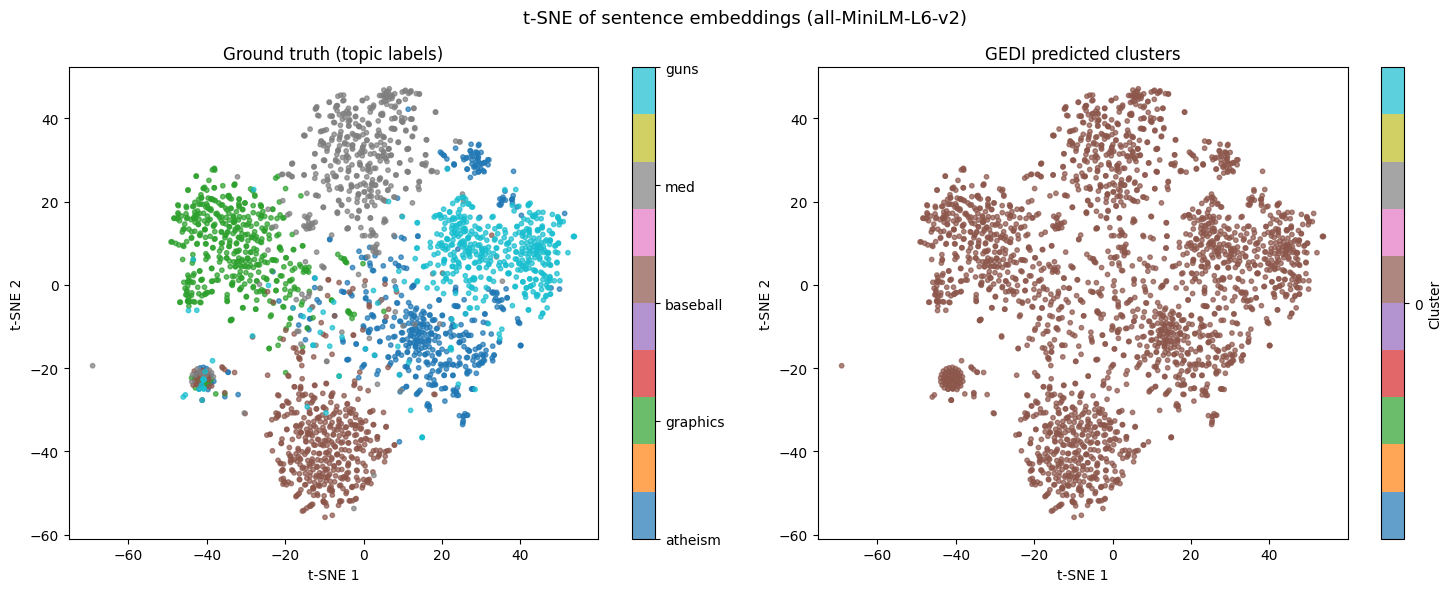

In [6]:
print("Running t-SNE (may take ~1–2 min for 2500 samples)…")
tsne = TSNE(n_components=2, perplexity=40, random_state=0, max_iter=1000)
X_2d = tsne.fit_transform(X)
print("Done.")

short_labels = [c.split('.')[-1] for c in CATEGORIES]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc0 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=10, alpha=0.7)
axes[0].set_title('Ground truth (topic labels)')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
cbar0 = plt.colorbar(sc0, ax=axes[0], ticks=range(N_CLUSTERS))
cbar0.ax.set_yticklabels(short_labels)

sc1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_pred_gedi, cmap='tab10', s=10, alpha=0.7)
axes[1].set_title('GEDI predicted clusters')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(sc1, ax=axes[1], ticks=range(N_CLUSTERS), label='Cluster')

plt.suptitle('t-SNE of sentence embeddings (all-MiniLM-L6-v2)', fontsize=13)
plt.tight_layout()
plt.show()


## 5.1 Tại sao GEDI bị cluster collapse trên dữ liệu văn bản?

**Cluster collapse** xảy ra khi mô hình gán gần như toàn bộ điểm dữ liệu vào một (hoặc rất ít) cụm, khiến các cụm còn lại rỗng hoặc gần rỗng. Dưới đây là các nguyên nhân cụ thể trong thí nghiệm này:

### 1. Không gian đầu vào quá cao chiều (384 chiều)
GEDI được thiết kế ban đầu cho dữ liệu đồ chơi 2 chiều. Khi đầu vào là embedding 384 chiều, **năng lượng (energy) giữa các điểm trở nên đồng đều** do "curse of dimensionality" — khoảng cách cosine giữa mọi cặp điểm co cụm về một giá trị, làm mất tín hiệu phân biệt cụm.

### 2. `lambda_prior` quá yếu so với chiều dữ liệu
- **L_PRIOR** phạt phân phối cluster assignment lệch khỏi phân phối đều.  
- Trong không gian 2 chiều (toy), `lambda_prior=10` đủ mạnh. Nhưng với 384 chiều, gradient của L_PRIOR nhỏ hơn nhiều bậc so với gradient của L_CLS (cross-entropy), khiến mô hình bỏ qua tín hiệu đều hóa và sụp đổ về một cụm duy nhất.
- Đây cũng phù hợp với **Định lý 2.2** (Chương 2): khi L_PRIOR không đủ mạnh, cluster collapse (Failure Mode 2) trở thành nghiệm tối ưu — mô hình hội tụ về trạng thái năng lượng thấp nhất mà không cần phân tách cụm.

### 3. L_INV (augmentation invariance) phản tác dụng ở chiều cao
- Nhiễu Gaussian `N(0, σ²I)` với σ=0.05 (mặc định) **cực kỳ nhỏ** so với norm chuẩn của embedding ~1.0 trong không gian 384 chiều: tỷ lệ nhiễu/tín hiệu ≈ 0.05/√384 ≈ 0.0026 — gần như không có augmentation.  
- Tăng lên σ=0.15 giúp nhưng vẫn có thể làm hai điểm gần nhau bị kéo về cùng cụm, **tăng áp lực collapse** nếu L_PRIOR không đủ mạnh bù lại.

### 4. L_GEN (SGLD) thêm nhiễu ngẫu nhiên không kiểm soát được
- SGLD sinh mẫu âm bằng cách thêm nhiễu Langevin. Trong không gian cao chiều, các mẫu âm này **phân tán ngẫu nhiên** thay vì tập trung ở vùng ranh giới cụm, khiến L_GEN đẩy năng lượng sai hướng và làm mất ổn định quá trình huấn luyện → tăng xác suất collapse.
- Việc tắt hoàn toàn L_GEN (`lambda_gen=0.0`) tương đương với cấu hình **GEDI no gen** trong ablation study (notebook 02) — kết quả ở đây nhất quán với quan sát rằng L_GEN không cải thiện (và đôi khi làm giảm) hiệu quả khi dữ liệu không phải ảnh.

### 5. Kiến trúc encoder chưa đủ sâu để học phân biệt
- Encoder MLP(384→128→64) chỉ có 1 hidden layer. Với embedding dense 384 chiều, mạng có thể **chưa đủ năng lực** để học một biểu diễn phân cụm tốt, dẫn đến encoder học cách "safe" nhất là ánh xạ mọi thứ vào một cụm.

### Tóm tắt và cách khắc phục đã áp dụng

| Vấn đề | Giải pháp trong notebook |
|--------|--------------------------|
| L_PRIOR quá yếu | Tăng `lambda_prior`: 10 → 100 → 200 |
| L_INV không hiệu quả | Tăng `aug_noise_std`: 0.05 → 0.15; giảm `lambda_inv`: 100 → 50 |
| L_GEN gây bất ổn | Tắt hoàn toàn: `lambda_gen=0.0` |
| Dự phòng nếu vẫn collapse | Step 2: tắt cả L_INV, tăng `lambda_prior=500` |

> **Kết luận:** GEDI chưa được thiết kế để xử lý embedding cao chiều — nó thiếu cơ chế chuẩn hóa (batch norm, layer norm) và scheduler learning rate giúp ổn định huấn luyện trong không gian lớn. KMeans không gặp vấn đề này vì nó tối ưu trực tiếp trên khoảng cách Euclidean mà không cần augmentation hay prior term.

> Kết quả này cho thấy GEDI, mặc dù có đảm bảo lý thuyết vững chắc, vẫn cần được **điều chỉnh hyperparameter cẩn thận** khi chuyển sang domain mới — một hạn chế thực tế quan trọng đã được phân tích trong **Section 3.2.2**.


## 6. Interpretation
- **Why 20 Newsgroups?** Text data is entirely out-of-distribution for the paper's vision-centric GEDI. This tests whether the energy-based clustering generalises beyond images.
- **Supervised metrics** (NMI, ARI, ACC): measure agreement between predicted clusters and ground-truth topics. Higher is better; 1.0 is perfect.
- **Unsupervised metrics** (Silhouette ↑, DBI ↓, CHI ↑): measure cluster quality without labels. These are the only metrics available in real-world deployment.
- **GEDI vs KMeans**: if GEDI's NMI ≈ KMeans, the energy-based approach adds limited value over a simple centroid method on text embeddings. KMeans is a strong baseline on normalised sentence vectors.
- **t-SNE**: cluster overlap in 2D does not necessarily indicate poor clustering — topics like `comp.graphics` and `sci.space` may share vocabulary and be harder to separate.